In [1]:
import io
import matplotlib.pyplot as plt
import os
import base64
from PIL import Image
import json
from inference_sdk import InferenceHTTPClient

C:\Users\laura\anaconda3\envs\cv\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


## Input images and output folder

In [2]:
image_folder = "./images/cars_side_profile/"
image_file_names = ["bmw.jpg", "renault.jpg", "vw_up.jpg", "lamborghini.jpg"]
output_folder = "./outputs/cars_dimensions/"

## Actual car dimensions

In [3]:
real_car_dimensions = { #length and height in cm, wheel_diameter_inches in inches
    "bmw": {
        "length_cm": 489.9,
        "height_cm": 146.4,
        "wheel_diameter_inches": 18
    },
    "renault": {
        "length_cm": 436.4,
        "height_cm": 143.5,
        "wheel_diameter_inches": 18
    },
    "vw_up": {
        "length_cm": 354.0,
        "height_cm": 148.9,
        "wheel_diameter_inches": 16
    },
    "lamborghini": {
        "length_cm": 478.0,
        "height_cm": 113.6,
        "wheel_diameter_inches": 20
    }
}

## Load Roboflow API key

In [4]:
with open("./roboflow_api_key.json", "r") as f:
    ROBOFLOW_API_KEY = json.load(f)["API_KEY"]

print(ROBOFLOW_API_KEY)

JHdm1Ivm2PmTD5VViuVN


## Run the workflow

In [5]:
client = InferenceHTTPClient(
    api_url="https://serverless.roboflow.com",
    api_key=ROBOFLOW_API_KEY
)

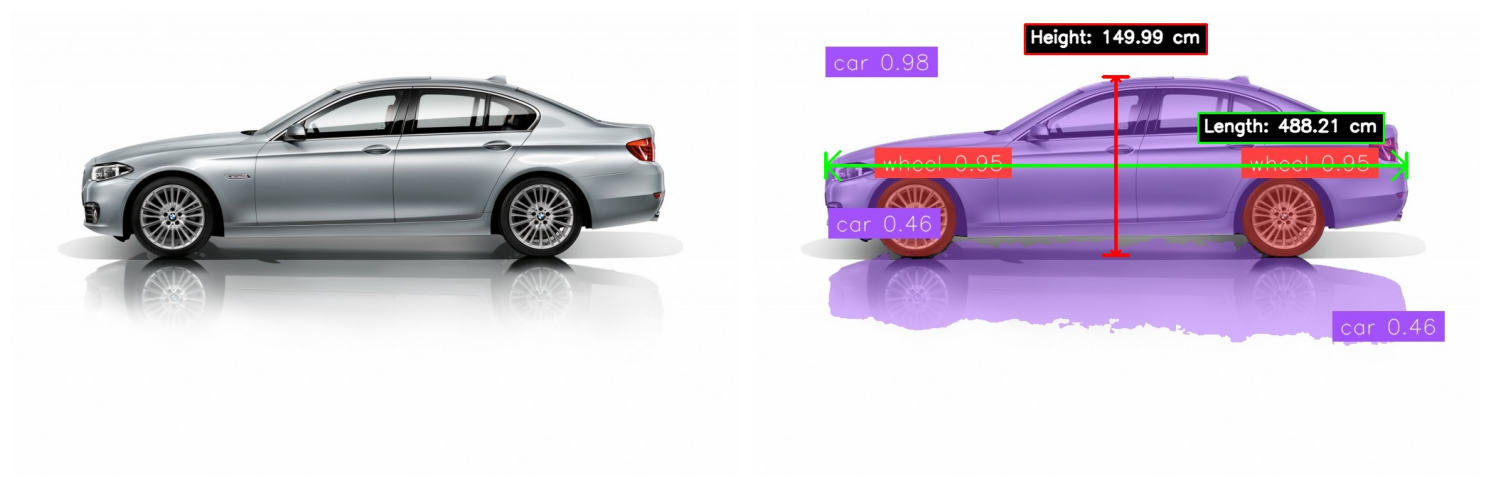

Measured length: 488.21cm and height: 149.99cm vs. actual length: 489.90cm and height: 146.40cm (difference of -1.69cm in length and 3.59cm in height)


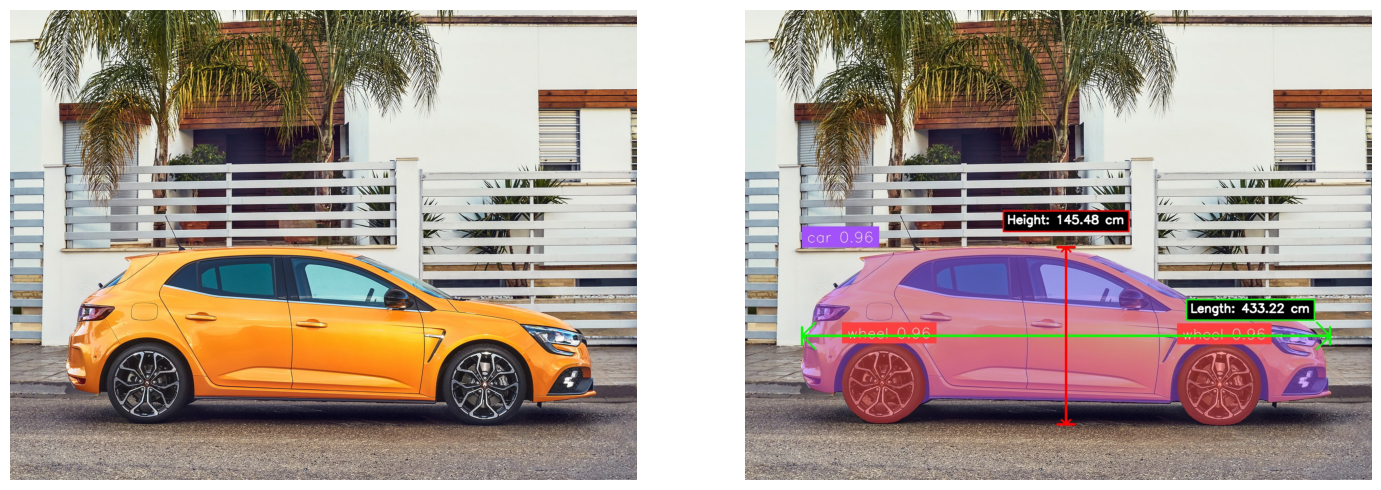

Measured length: 433.22cm and height: 145.48cm vs. actual length: 436.40cm and height: 143.50cm (difference of -3.18cm in length and 1.98cm in height)


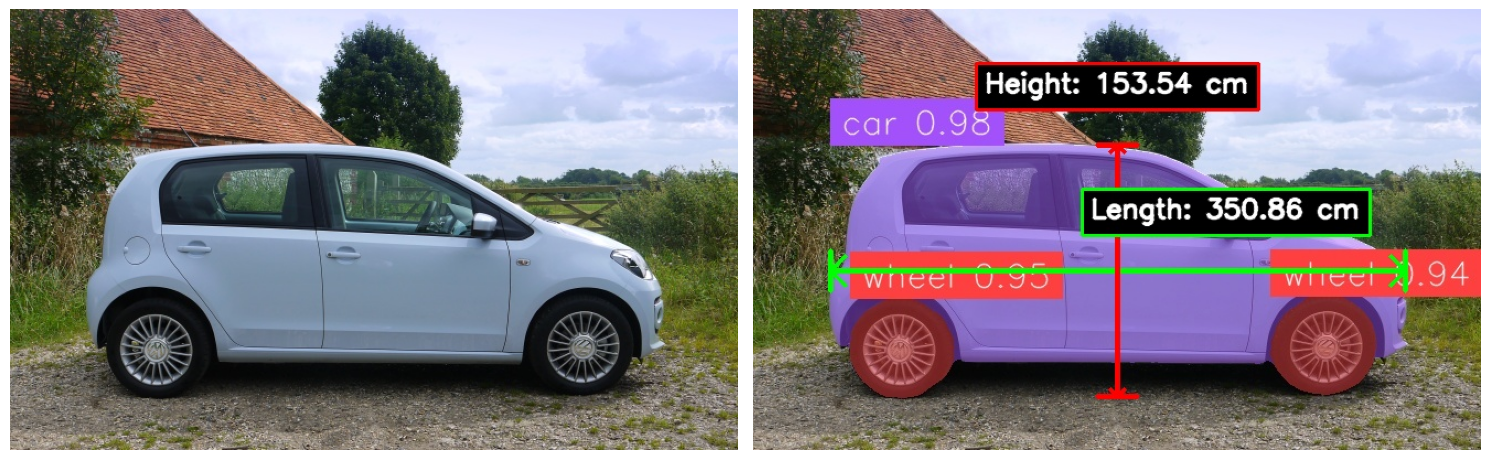

Measured length: 350.86cm and height: 153.54cm vs. actual length: 354.00cm and height: 148.90cm (difference of -3.14cm in length and 4.64cm in height)


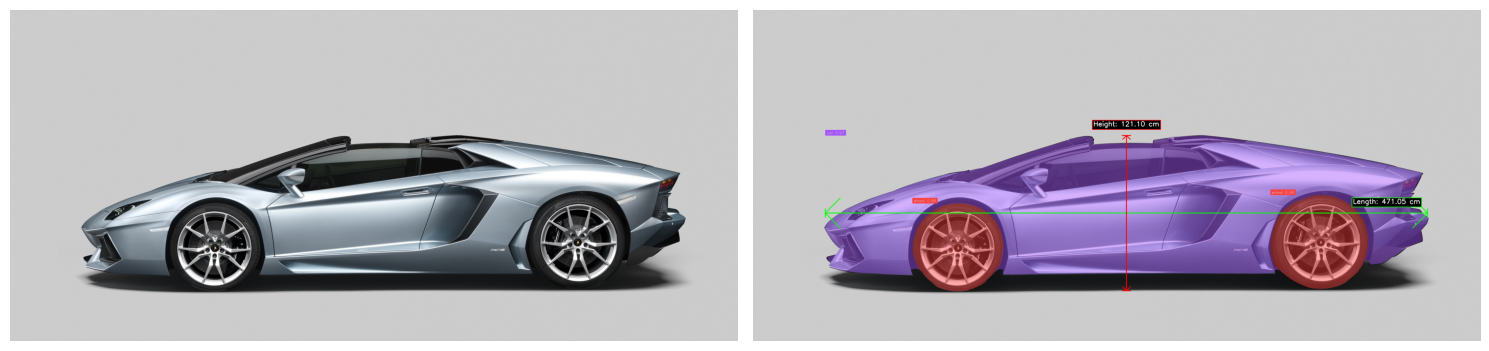

Measured length: 471.05cm and height: 121.10cm vs. actual length: 478.00cm and height: 113.60cm (difference of -6.95cm in length and 7.50cm in height)


In [6]:
for file_name in image_file_names:
    image_path = image_folder + file_name
    car_key = file_name.split('.')[0]
    real_car_dimension = real_car_dimensions[car_key]

    #run the workflow
    result = client.run_workflow(
        workspace_name = "domen-k",
        workflow_id = "car-height-and-length-side-view",
        images={
            "image": image_path
        },
        parameters={
            "wheel_diameter_inches": real_car_dimension["wheel_diameter_inches"]
        }
    )

    #plot the input and output images
    image_bytes = base64.b64decode(result[0]['output_image'])
    img = Image.open(io.BytesIO(image_bytes))
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].imshow(Image.open(image_path))
    axes[1].imshow(img)
    axes[0].axis('off')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

    #print difference vs. actual length/height
    pred_measurements = result[0]['measurements_cm']
    length_diff = pred_measurements['length_cm'] - real_car_dimension['length_cm']
    height_diff = pred_measurements['height_cm'] - real_car_dimension['height_cm']
    print(f"Measured length: {pred_measurements['length_cm']:.2f}cm and height: {pred_measurements['height_cm']:.2f}cm "
          f"vs. actual length: {real_car_dimension['length_cm']:.2f}cm and height: {real_car_dimension['height_cm']:.2f}cm "
          f"(difference of {length_diff:.2f}cm in length and {height_diff:.2f}cm in height)")

    #save output to disk
    os.makedirs(output_folder, exist_ok=True)
    img.save(output_folder + file_name)